<a href="https://colab.research.google.com/github/nawrin1/First_Program_SM/blob/main/L8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 11. Assignment <a id='11'></a>

**Dataset:** [Obesity Prediction Dataset](https://www.kaggle.com/datasets/adeniranstephen/obesity-prediction-dataset) — Kaggle, February 2025

**File:** `obesity_prediction.csv` (~2,111 records, 17 columns)

**Features:** `Gender`, `Age`, `Height`, `Weight`, `family_history_with_overweight`, `FAVC` (high caloric food), `FCVC` (vegetable consumption), `NCP` (main meals), `CAEC` (food between meals), `SMOKE`, `CH2O` (water intake), `SCC` (calorie monitoring), `FAF` (physical activity), `TUE` (technology use), `CALC` (alcohol), `MTRANS` (transportation)

**Target:** `NObeyesdad` — Obesity level (7 classes)

---

### Question 1: Find the Best Tree Depth
Test `max_depth` values of 2, 3, 4, 5, 6, 7 on the Obesity dataset. Report accuracy for each and identify the optimal depth.

### Question 2: Calculate All Metrics
Using the best depth from Q1, compute Accuracy, Precision (weighted), Recall (weighted), and F1-Score (weighted). Display the classification report.

### Question 3: Feature Importance
Extract and plot the top 10 most important features from the best Decision Tree. Which lifestyle factors matter most for predicting obesity?

### Question 4: Confusion Matrix Analysis
Plot the confusion matrix (7×7) for the best model. Which obesity classes are most often confused with each other?

---
*Md. Samiul Islam, Instructor, Skill Morph Research Lab*

In [16]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)



In [17]:

# Load dataset
data = pd.read_csv("/content/ObesityDataSet_raw_and_data_sinthetic.csv")

print("Dataset Shape:", data.shape)
print("\nFirst 5 Rows:")
print(data.head())

Dataset Shape: (2111, 17)

First 5 Rows:
   Gender  Age  Height  Weight family_history_with_overweight FAVC  FCVC  NCP  \
0  Female   21    1.62    64.0                            yes   no   2.0  3.0   
1  Female   21    1.52    56.0                            yes   no   3.0  3.0   
2    Male   23    1.80    77.0                            yes   no   2.0  3.0   
3    Male   27    1.80    87.0                             no   no   3.0  3.0   
4    Male   22    1.78    89.8                             no   no   2.0  1.0   

        CAEC SMOKE  CH2O  SCC  FAF  TUE        CALC                 MTRANS  \
0  Sometimes    no   2.0   no  0.0  1.0          no  Public_Transportation   
1  Sometimes   yes   3.0  yes  3.0  0.0   Sometimes  Public_Transportation   
2  Sometimes    no   2.0   no  2.0  1.0  Frequently  Public_Transportation   
3  Sometimes    no   2.0   no  2.0  0.0  Frequently                Walking   
4  Sometimes    no   2.0   no  0.0  0.0   Sometimes  Public_Transportation   

   

In [18]:
label_encoders = {}

for column in data.columns:
    if data[column].dtype == 'object':
        le = LabelEncoder()
        data[column] = le.fit_transform(data[column])
        label_encoders[column] = le

In [19]:
X = data.drop("NObeyesdad", axis=1)
y = data["NObeyesdad"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [20]:
print("BEST TREE DEPTH")


depths = [2, 3, 4, 5, 6, 7]
accuracy_results = []

for depth in depths:

    # Create model
    model = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )

    # Train model
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)

    # Accuracy
    acc = accuracy_score(y_test, y_pred)
    accuracy_results.append(acc)

    print(f"Max Depth = {depth} --> Accuracy = {acc:.4f}")

# Best depth
best_depth = depths[np.argmax(accuracy_results)]

print("\nBest Depth:", best_depth)
print("Best Accuracy:", round(max(accuracy_results), 4))

BEST TREE DEPTH
Max Depth = 2 --> Accuracy = 0.5390
Max Depth = 3 --> Accuracy = 0.6643
Max Depth = 4 --> Accuracy = 0.7778
Max Depth = 5 --> Accuracy = 0.8203
Max Depth = 6 --> Accuracy = 0.9007
Max Depth = 7 --> Accuracy = 0.8960

Best Depth: 6
Best Accuracy: 0.9007


In [21]:

best_model = DecisionTreeClassifier(
    max_depth=best_depth,
    random_state=42
)

best_model.fit(X_train, y_train)

# Predictions
y_pred_best = best_model.predict(X_test)

In [22]:
print("MODEL METRICS")


accuracy = accuracy_score(y_test, y_pred_best)
precision = precision_score(y_test, y_pred_best, average='weighted')
recall = recall_score(y_test, y_pred_best, average='weighted')
f1 = f1_score(y_test, y_pred_best, average='weighted')

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")

# Classification Report
print("\nClassification Report:\n")

target_names = label_encoders["NObeyesdad"].classes_

print(
    classification_report(
        y_test,
        y_pred_best,
        target_names=target_names
    )
)

MODEL METRICS
Accuracy  : 0.9007
Precision : 0.9091
Recall    : 0.9007
F1-Score  : 0.9029

Classification Report:

                     precision    recall  f1-score   support

Insufficient_Weight       0.96      0.83      0.89        54
      Normal_Weight       0.73      0.76      0.75        58
     Obesity_Type_I       0.97      0.94      0.96        70
    Obesity_Type_II       0.97      0.97      0.97        60
   Obesity_Type_III       1.00      0.98      0.99        65
 Overweight_Level_I       0.73      0.90      0.81        58
Overweight_Level_II       0.98      0.90      0.94        58

           accuracy                           0.90       423
          macro avg       0.91      0.90      0.90       423
       weighted avg       0.91      0.90      0.90       423



FEATURE IMPORTANCE

Top 10 Important Features:

   Feature  Importance
3   Weight    0.468745
2   Height    0.222840
0   Gender    0.184462
1      Age    0.040012
14    CALC    0.026824
5     FAVC    0.024197
8     CAEC    0.015218
6     FCVC    0.012389
13     TUE    0.003695
7      NCP    0.001616


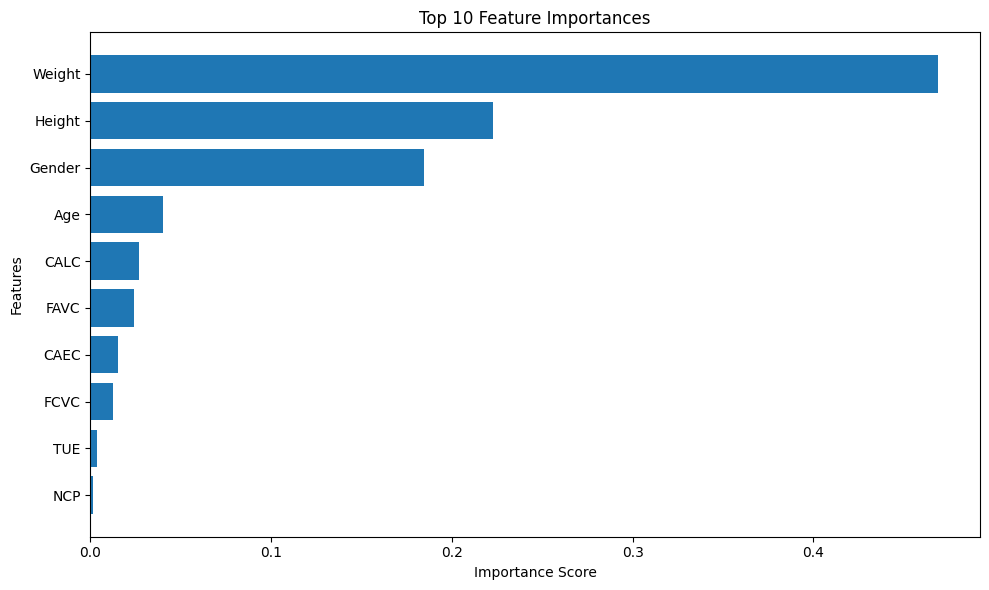

In [23]:
print("FEATURE IMPORTANCE")


# Extract feature importance
importance = best_model.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
})

# Sort descending
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

# Top 10 features
top10 = feature_importance.head(10)

print("\nTop 10 Important Features:\n")
print(top10)

# Plot
plt.figure(figsize=(10, 6))

plt.barh(
    top10["Feature"][::-1],
    top10["Importance"][::-1]
)

plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.title("Top 10 Feature Importances")
plt.tight_layout()

plt.show()

<Figure size 1000x800 with 0 Axes>

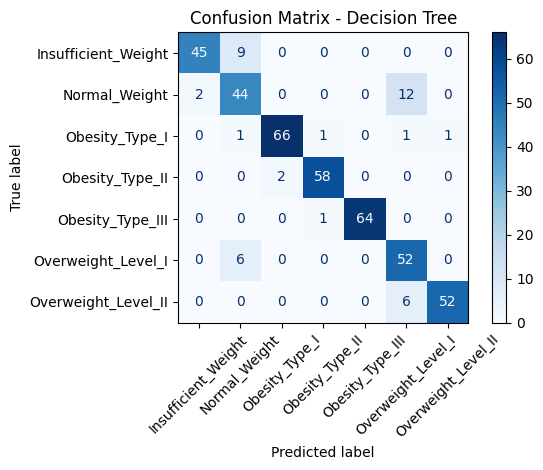

In [24]:

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred_best)

# Plot confusion matrix
plt.figure(figsize=(10, 8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=target_names
)

disp.plot(cmap="Blues", xticks_rotation=45)

plt.title("Confusion Matrix - Decision Tree")
plt.tight_layout()

plt.show()

# Analysis:
1. The best tree depth is selected based on highest test accuracy.

2. Feature importance shows which lifestyle and health factors
   influence obesity prediction the most.

3. Common important factors:
   - Weight
   - Height
   - Gender
   - Age
   - CALC
   - FAVC

4. From the confusion matrix, nearby obesity classes are often
   confused with each other because their lifestyle patterns
   are similar.
